# 多吸引子三变量动力系统相图

这个 notebook 构造一个三变量非负 ODE。系统同时具有原点吸引子和多个单模块激活吸引子，用来展示“多变量协同/竞争网络”如何产生多稳态。

图不写入外部文件，只在 notebook 中直接展示。

## 模型

令 $\mathbf{x}=(x_0,x_1,x_2)\ge 0$。每个变量代表一个可自维持的功能模块或命运程序。

\begin{aligned}
\dot{x}_i &= x_i\left[-\mu_i + a_i H_i(x_i) - c_i x_i - \sum_{j\ne i}\beta_{ij}x_j\right],\\
H_i(x_i) &= \frac{x_i^n}{K_i^n+x_i^n}.
\end{aligned}

含义：

- $x_i$ 前因子保证非负正交区域不变，且原点是一个吸引子。
- $H_i(x_i)$ 是协同性自激活；低于阈值时模块衰减，高于阈值后可自维持。
- 非对称 $\beta_{ij}$ 是模块间互抑，促成 winner-take-all 型吸引子，并让不同节点的一对其余节点协同产生差异。

在当前参数下，目标结构是至少四个稳定吸引子：

\begin{aligned}
A_0 &\approx (0,0,0),\\
A_1 &\approx (h_0,0,0),\\
A_2 &\approx (0,h_1,0),\\
A_3 &\approx (0,0,h_2).
\end{aligned}

In [ ]:
from __future__ import annotations

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.dpi": 130,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

SEED = 17
rng = np.random.default_rng(SEED)
SEED

In [ ]:
PARAMS = {
    "mu": np.array([0.21, 0.16, 0.18]),      # basal decay/growth penalty; makes the origin locally stable
    "a": np.array([1.42, 1.78, 1.56]),       # node-specific self-activation gain
    "K": np.array([0.56, 0.40, 0.48]),       # node-specific self-activation threshold
    "n": 4.0,                                # Hill coefficient; cooperativity
    "crowd": np.array([0.40, 0.28, 0.34]),   # within-module saturation
    "beta": np.array([                       # beta[i, j]: inhibition from x_j to x_i
        [0.00, 1.15, 1.65],
        [1.45, 0.00, 1.10],
        [0.95, 1.80, 0.00],
    ]),
}

T_FINAL = 54.0
DT = 0.03
X_MAX = 5.4

ATTRACTOR_NAMES = np.array(["A0 origin", "A1 x0-high", "A2 x1-high", "A3 x2-high"])
ATTRACTOR_COLORS = np.array(["#6b7280", "#2563eb", "#dc2626", "#16a34a"])


def hill(x, K=PARAMS["K"], n=PARAMS["n"]):
    x = np.maximum(np.asarray(x, dtype=float), 0.0)
    return x**n / (K**n + x**n + 1e-12)


def rhs(X, params=PARAMS):
    X = np.maximum(np.asarray(X, dtype=float), 0.0)
    inhibition = X @ np.asarray(params["beta"], dtype=float).T
    growth = (
        -np.asarray(params["mu"], dtype=float)
        + np.asarray(params["a"], dtype=float) * hill(X, params["K"], params["n"])
        - np.asarray(params["crowd"], dtype=float) * X
        - inhibition
    )
    return X * growth


def integrate_rk4(X0, t_final=T_FINAL, dt=DT):
    X = np.asarray(X0, dtype=float).copy()
    steps = int(round(t_final / dt))
    for _ in range(steps):
        k1 = rhs(X)
        k2 = rhs(np.maximum(X + 0.5 * dt * k1, 0.0))
        k3 = rhs(np.maximum(X + 0.5 * dt * k2, 0.0))
        k4 = rhs(np.maximum(X + dt * k3, 0.0))
        X = np.maximum(X + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0, 0.0)
    return X


def trajectory(x0, t_final=T_FINAL, dt=DT):
    x = np.asarray(x0, dtype=float).copy()
    steps = int(round(t_final / dt))
    path = np.empty((steps + 1, 3), dtype=float)
    path[0] = x
    for step in range(steps):
        k1 = rhs(x)
        k2 = rhs(np.maximum(x + 0.5 * dt * k1, 0.0))
        k3 = rhs(np.maximum(x + 0.5 * dt * k2, 0.0))
        k4 = rhs(np.maximum(x + dt * k3, 0.0))
        x = np.maximum(x + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0, 0.0)
        path[step + 1] = x
    return path


def classify_endpoint(Y, origin_threshold=0.35):
    Y = np.asarray(Y, dtype=float)
    labels = np.zeros(Y.shape[:-1], dtype=int)
    high = Y.max(axis=-1) >= origin_threshold
    labels[high] = 1 + np.argmax(Y[high], axis=-1)
    return labels


def estimate_axis_attractors():
    probes = np.array([
        [0.0, 0.0, 0.0],
        [0.9, 0.0, 0.0],
        [0.0, 0.9, 0.0],
        [0.0, 0.0, 0.9],
    ])
    return integrate_rk4(probes, t_final=70.0, dt=0.035)


ATTRACTOR_POINTS = estimate_axis_attractors()

## 吸引子检查

先从代表性初值出发积分，确认原点和三个单模块高态都能吸引邻域内轨道。

In [ ]:
probe_initials = np.array([
    [0.00, 0.00, 0.00],
    [0.20, 0.00, 0.00],
    [0.75, 0.00, 0.00],
    [0.00, 0.75, 0.00],
    [0.00, 0.00, 0.75],
    [1.00, 1.00, 1.00],
    [1.50, 1.20, 0.20],
    [0.25, 1.10, 0.40],
])
probe_endpoints = integrate_rk4(probe_initials)
probe_labels = classify_endpoint(probe_endpoints)

print("parameters:", PARAMS)
print("\ninitial -> endpoint -> attractor")
for x0, xT, label in zip(probe_initials, probe_endpoints, probe_labels):
    print(f"{np.round(x0, 3)} -> {np.round(xT, 4)} -> {ATTRACTOR_NAMES[label]}")

## 二维切片相图

每张图固定一个变量为 0。背景颜色表示该切片上初值最终进入的 basin；箭头表示局部向量场；黑色轨线显示典型初值的流向。

In [ ]:
def basin_slice(var_a, var_b, fixed_var, fixed_value=0.0, grid_n=115):
    grid = np.linspace(0.0, X_MAX, grid_n)
    A, B = np.meshgrid(grid, grid, indexing="xy")
    X0 = np.zeros((grid_n, grid_n, 3), dtype=float)
    X0[..., var_a] = A
    X0[..., var_b] = B
    X0[..., fixed_var] = fixed_value
    endpoints = integrate_rk4(X0.reshape(-1, 3)).reshape(grid_n, grid_n, 3)
    labels = classify_endpoint(endpoints)
    return grid, A, B, labels


def draw_phase_slice(ax, var_a, var_b, fixed_var, fixed_value=0.0):
    grid, A, B, labels = basin_slice(var_a, var_b, fixed_var, fixed_value=fixed_value)
    cmap = mpl.colors.ListedColormap(ATTRACTOR_COLORS)
    norm = mpl.colors.BoundaryNorm(np.arange(-0.5, 4.5, 1.0), cmap.N)
    ax.pcolormesh(A, B, labels, cmap=cmap, norm=norm, shading="auto", alpha=0.24)

    q = np.linspace(0.0, X_MAX, 21)
    QA, QB = np.meshgrid(q, q, indexing="xy")
    QX = np.zeros((q.size, q.size, 3), dtype=float)
    QX[..., var_a] = QA
    QX[..., var_b] = QB
    QX[..., fixed_var] = fixed_value
    V = rhs(QX.reshape(-1, 3)).reshape(q.size, q.size, 3)
    U = V[..., var_a]
    W = V[..., var_b]
    speed = np.hypot(U, W)
    U = np.divide(U, speed, out=np.zeros_like(U), where=speed > 1e-10)
    W = np.divide(W, speed, out=np.zeros_like(W), where=speed > 1e-10)
    ax.quiver(QA, QB, U, W, color="0.2", alpha=0.42, width=0.0022, scale=32)

    starts = np.array([
        [0.12, 0.12], [0.50, 0.20], [0.20, 0.50], [0.95, 0.35],
        [0.35, 0.95], [1.30, 1.20], [2.20, 0.65], [0.65, 2.20],
    ])
    for start in starts:
        x0 = np.zeros(3, dtype=float)
        x0[var_a], x0[var_b], x0[fixed_var] = start[0], start[1], fixed_value
        path = trajectory(x0, t_final=34.0, dt=0.04)
        ax.plot(path[:, var_a], path[:, var_b], color="black", lw=0.8, alpha=0.58)

    marker_points = ATTRACTOR_POINTS
    for idx, point in enumerate(marker_points):
        if abs(point[fixed_var] - fixed_value) < 1e-8:
            ax.scatter(point[var_a], point[var_b], s=46, color=ATTRACTOR_COLORS[idx], edgecolor="white", linewidth=0.8, zorder=5)
            ax.text(point[var_a] + 0.08, point[var_b] + 0.08, ATTRACTOR_NAMES[idx].split()[0], fontsize=8, color="0.1")

    ax.set_xlim(0, X_MAX)
    ax.set_ylim(0, X_MAX)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"x{var_a}")
    ax.set_ylabel(f"x{var_b}")
    ax.text(0.04, 0.96, f"x{fixed_var} = {fixed_value:g}", transform=ax.transAxes, va="top", ha="left", fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.6), constrained_layout=True)
draw_phase_slice(axes[0], 0, 1, 2)
draw_phase_slice(axes[1], 0, 2, 1)
draw_phase_slice(axes[2], 1, 2, 0)
plt.show()

## 三维 basin of attraction

下面在三维初值空间中采样，颜色表示轨道最终落入的吸引子。原点 basin 和三个单模块 basin 同时存在。

In [ ]:
grid = np.linspace(0.0, 2.6, 17)
X0 = np.array(np.meshgrid(grid, grid, grid, indexing="ij")).reshape(3, -1).T
XT = integrate_rk4(X0, t_final=46.0, dt=0.035)
labels = classify_endpoint(XT)

counts = {ATTRACTOR_NAMES[i]: int(np.sum(labels == i)) for i in range(4)}
counts

In [ ]:
fig = plt.figure(figsize=(6.2, 5.2), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

# Downsample only visually; classification used all grid points above.
for label in range(4):
    mask = labels == label
    pts = X0[mask]
    ax.scatter(
        pts[:, 0], pts[:, 1], pts[:, 2],
        s=12 if label else 9,
        color=ATTRACTOR_COLORS[label],
        alpha=0.62 if label else 0.38,
        depthshade=False,
    )

attractor_points = ATTRACTOR_POINTS
for label, point in enumerate(attractor_points):
    ax.scatter(*point, s=76, color=ATTRACTOR_COLORS[label], edgecolor="white", linewidth=0.9, depthshade=False)
    ax.text(*(point + 0.10), ATTRACTOR_NAMES[label].split()[0], fontsize=8)

ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_zlabel("x2")
ax.set_xlim(0, X_MAX)
ax.set_ylim(0, X_MAX)
ax.set_zlim(0, X_MAX)
ax.view_init(elev=24, azim=-48)
plt.show()

print("basin sample counts")
for name, count in counts.items():
    print(f"{name}: {count}")

## 读图结论

这个例子展示了一个最小的多变量多吸引子结构：原点由基底衰减稳定，三个高态由协同性自激活维持，模块间互抑把混合高态排斥出去。改变初始条件或外部干预可让轨道跨过 basin boundary，从一个吸引子切换到另一个吸引子。

## 单节点-其余节点对整体系统的协同

下面把三维初始状态 $\mathbf{x}(0)$ 作为源，把自由演化后的整体终态 $\mathbf{x}(\tau)$ 作为目标。对每个节点 $i$，计算二分源侧协同：

\begin{aligned}
\mathrm{Syn}_i = EI\left((x_i, \mathbf{x}_{\neg i}); \mathbf{x}(\tau)\right) - EI\left(x_i; \mathbf{x}(\tau)\right) - EI\left(\mathbf{x}_{\neg i}; \mathbf{x}(\tau)\right).
\end{aligned}

这里的 $\mathbf{x}_{\neg i}$ 表示另外两个节点。参数已经故意设成非对称，所以三项协同不应打平。

In [13]:
from pathlib import Path
import sys
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "exp" / "TM" / "transport_map_density.py").exists():
    for parent in repo_root.parents:
        if (parent / "exp" / "TM" / "transport_map_density.py").exists():
            repo_root = parent
            break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from exp.TM.transport_map_density import estimate_mutual_information_transport_map

SYNERGY_SAMPLE_COUNT = 2500
SYNERGY_TAU = 46.0
SYNERGY_DT = 0.04
SYNERGY_STATE_HIGH = 4.2
SYNERGY_TARGET_NOISE_FRACTION = 0.0
SYNERGY_SEED = 123


def lift_source_features(Z):
    Z = np.asarray(Z, dtype=float)
    if Z.ndim == 1:
        Z = Z[:, None]
    if Z.ndim != 2 or Z.shape[1] < 1:
        raise ValueError("Z must have shape [sample, source_dim].")

    features = [Z, Z**2, Z**3]
    if Z.shape[1] >= 2:
        pairwise = []
        for left in range(Z.shape[1]):
            for right in range(left + 1, Z.shape[1]):
                pairwise.append((Z[:, left] * Z[:, right])[:, None])
        features.append(np.hstack(pairwise))
    if Z.shape[1] >= 3:
        features.append(np.prod(Z, axis=1, keepdims=True))
    return np.hstack(features)


def estimate_lifted_ei(source, target):
    summary = estimate_mutual_information_transport_map(lift_source_features(source), target)
    return max(0.0, float(summary["mi_hat"])), float(summary["bias_correction"])


def estimate_bipartition_synergy(initial_states, final_states, *, target_noise_fraction=0.0, seed=0):
    initial_states = np.asarray(initial_states, dtype=float)
    final_states = np.asarray(final_states, dtype=float)
    if target_noise_fraction > 0.0:
        rng_local = np.random.default_rng(seed)
        sigma = np.maximum(1e-6, target_noise_fraction * final_states.std(axis=0, ddof=1))
        target = final_states + sigma * rng_local.normal(size=final_states.shape)
    else:
        sigma = np.zeros(final_states.shape[1], dtype=float)
        target = final_states

    joint_ei, joint_bias = estimate_lifted_ei(initial_states, target)
    rows = []
    for node in range(initial_states.shape[1]):
        rest = [idx for idx in range(initial_states.shape[1]) if idx != node]
        single_ei, single_bias = estimate_lifted_ei(initial_states[:, [node]], target)
        rest_ei, rest_bias = estimate_lifted_ei(initial_states[:, rest], target)
        rows.append({
            "node": int(node),
            "split": f"x{node} | rest",
            "single_ei": single_ei,
            "rest_ei": rest_ei,
            "joint_ei": joint_ei,
            "synergy": joint_ei - single_ei - rest_ei,
            "single_bias_correction": single_bias,
            "rest_bias_correction": rest_bias,
            "joint_bias_correction": joint_bias,
            "target_noise_sigma_mean": float(np.mean(sigma)),
        })
    table = pd.DataFrame(rows).sort_values("synergy", ascending=False).reset_index(drop=True)
    table["rank_synergy"] = np.arange(1, len(table) + 1, dtype=int)
    return table


rng_synergy = np.random.default_rng(SYNERGY_SEED)
synergy_initial_states = rng_synergy.uniform(
    0.0,
    SYNERGY_STATE_HIGH,
    size=(SYNERGY_SAMPLE_COUNT, 3),
)
synergy_final_states = integrate_rk4(synergy_initial_states, t_final=SYNERGY_TAU, dt=SYNERGY_DT)

synergy_table = estimate_bipartition_synergy(
    synergy_initial_states,
    synergy_final_states,
    target_noise_fraction=SYNERGY_TARGET_NOISE_FRACTION,
    seed=SYNERGY_SEED + 1,
)
synergy_table[["rank_synergy", "split", "single_ei", "rest_ei", "joint_ei", "synergy"]]

,rank_synergy,split,single_ei,rest_ei,joint_ei,synergy
0,1,x2 | rest,0.173174,0.635208,1.179269,0.370887
1,2,x1 | rest,0.460013,0.348941,1.179269,0.370316
2,3,x0 | rest,0.081579,0.835338,1.179269,0.262352


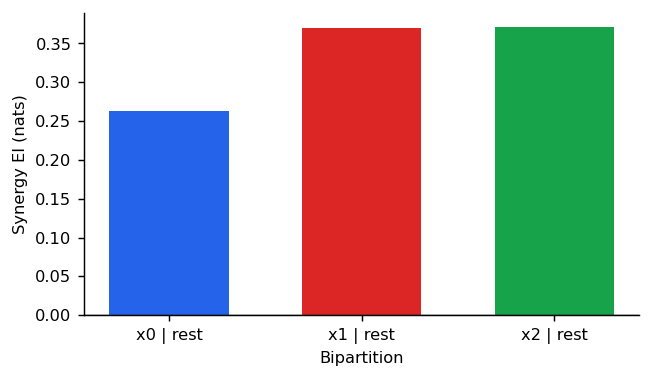

synergy spread = 0.108535 nats


In [14]:
fig, ax = plt.subplots(figsize=(4.9, 2.8), constrained_layout=True)
plot_table = synergy_table.sort_values("node")
ax.bar(
    plot_table["split"],
    plot_table["synergy"],
    color=[ATTRACTOR_COLORS[int(node) + 1] for node in plot_table["node"]],
    width=0.62,
)
ax.axhline(0.0, color="0.2", lw=0.8)
ax.set_ylabel("Synergy EI (nats)")
ax.set_xlabel("Bipartition")
ax.tick_params(axis="x", rotation=0)
plt.show()

synergy_spread = float(synergy_table["synergy"].max() - synergy_table["synergy"].min())
print(f"synergy spread = {synergy_spread:.6f} nats")

## 持续单节点干预成本对照

这里把干预改成持续夹持协议：从一批接近原点 basin 的基准初值出发，在时间区间 $[0,T]$ 内把节点 $x_i$ 固定为 $\Delta$，然后释放系统自由演化。若最终进入该节点对应的高态 basin，就记为一次成功。

核心成本定义为

\begin{aligned}
C_i(\Delta,T)=\Delta T.
\end{aligned}

对每个节点扫描 $(\Delta,T)$，取达到成功率阈值的最小成本 $C_i^*$，再比较 $\mathrm{Syn}_i$ 与 $C_i^*$ 是否呈负相关。

In [15]:
INTERVENTION_SEED = 321
INTERVENTION_BASE_COUNT = 160
INTERVENTION_BASE_HIGH = 0.22
INTERVENTION_DELTA_GRID = np.linspace(0.10, 1.40, 14)
INTERVENTION_DURATION_GRID = np.linspace(0.25, 6.00, 13)
INTERVENTION_RELEASE_T = 42.0
INTERVENTION_DT = 0.05
INTERVENTION_SUCCESS_THRESHOLD = 0.95


def integrate_rk4_clamped_node(X0, *, node, delta, duration, dt=INTERVENTION_DT):
    X = np.asarray(X0, dtype=float).copy()
    node = int(node)
    delta = float(delta)
    X[:, node] = delta

    def clamped_rhs(Y):
        Y = np.maximum(np.asarray(Y, dtype=float), 0.0).copy()
        Y[:, node] = delta
        dY = rhs(Y)
        dY[:, node] = 0.0
        return dY

    t = 0.0
    while t < float(duration) - 1e-12:
        step = min(float(dt), float(duration) - t)
        k1 = clamped_rhs(X)
        k2 = clamped_rhs(np.maximum(X + 0.5 * step * k1, 0.0))
        k3 = clamped_rhs(np.maximum(X + 0.5 * step * k2, 0.0))
        k4 = clamped_rhs(np.maximum(X + step * k3, 0.0))
        X = np.maximum(X + step * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0, 0.0)
        X[:, node] = delta
        t += step
    return X


def simulate_sustained_single_node_intervention(node, delta_grid, duration_grid, base_initials):
    rows = []
    node = int(node)
    for delta in np.asarray(delta_grid, dtype=float):
        for duration in np.asarray(duration_grid, dtype=float):
            after_clamp = integrate_rk4_clamped_node(
                base_initials,
                node=node,
                delta=delta,
                duration=duration,
                dt=INTERVENTION_DT,
            )
            clamp_labels = classify_endpoint(after_clamp)
            endpoints = integrate_rk4(after_clamp, t_final=INTERVENTION_RELEASE_T, dt=INTERVENTION_DT)
            labels = classify_endpoint(endpoints)
            rows.append({
                "node": node,
                "delta": float(delta),
                "duration": float(duration),
                "intervention_cost": float(delta * duration),
                "energy_cost": float(delta**2 * duration),
                "target_basin_at_release_fraction": float(np.mean(clamp_labels == node + 1)),
                "target_basin_fraction": float(np.mean(labels == node + 1)),
                "final_mean": float(endpoints.mean()),
                "intervened_node_final_mean": float(endpoints[:, node].mean()),
            })
    return pd.DataFrame(rows)


rng_intervention = np.random.default_rng(INTERVENTION_SEED)
base_initials = rng_intervention.uniform(
    0.0,
    INTERVENTION_BASE_HIGH,
    size=(INTERVENTION_BASE_COUNT, 3),
)
base_labels = classify_endpoint(integrate_rk4(base_initials, t_final=INTERVENTION_RELEASE_T, dt=INTERVENTION_DT))
print("baseline basin fractions:", {ATTRACTOR_NAMES[i]: float(np.mean(base_labels == i)) for i in range(4)})

intervention_response = pd.concat(
    [
        simulate_sustained_single_node_intervention(
            node,
            INTERVENTION_DELTA_GRID,
            INTERVENTION_DURATION_GRID,
            base_initials,
        )
        for node in range(3)
    ],
    ignore_index=True,
)
intervention_response.head()

baseline basin fractions: {'A0 origin': 1.0, 'A1 x0-high': 0.0, 'A2 x1-high': 0.0, 'A3 x2-high': 0.0}


,node,delta,duration,intervention_cost,energy_cost,target_basin_at_release_fraction,target_basin_fraction,final_mean,intervened_node_final_mean
0,0,0.1,0.250000,0.025000,0.002500,0.0,0.0,0.000024,0.000005
1,0,0.1,0.729167,0.072917,0.007292,0.0,0.0,0.000022,0.000006
2,0,0.1,1.208333,0.120833,0.012083,0.0,0.0,0.000019,0.000007
3,0,0.1,1.687500,0.168750,0.016875,0.0,0.0,0.000017,0.000007
4,0,0.1,2.166667,0.216667,0.021667,0.0,0.0,0.000015,0.000008


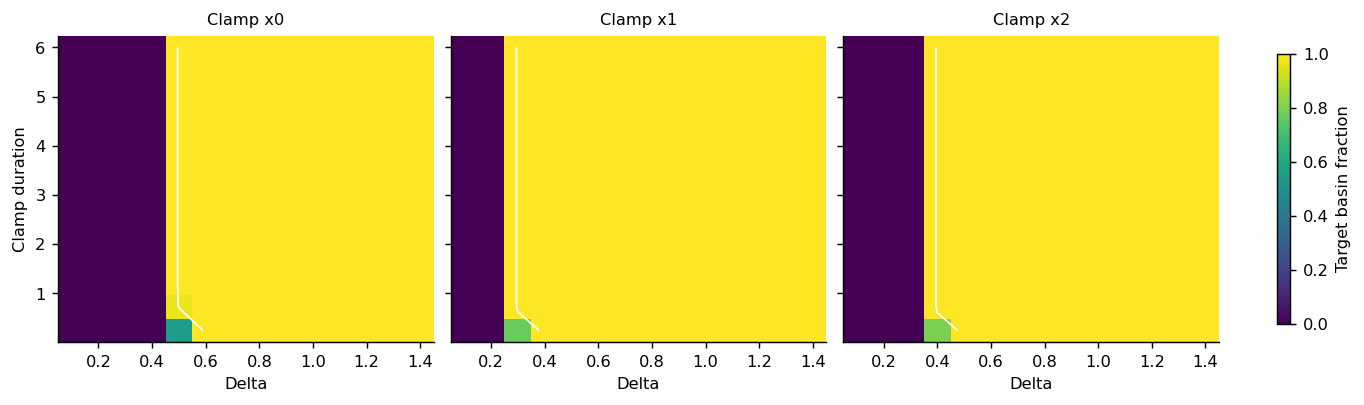

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.0), constrained_layout=True, sharex=True, sharey=True)
for node, ax in enumerate(axes):
    grid = intervention_response.loc[intervention_response["node"].eq(node)].pivot(
        index="duration",
        columns="delta",
        values="target_basin_fraction",
    )
    mesh = ax.pcolormesh(
        grid.columns.to_numpy(dtype=float),
        grid.index.to_numpy(dtype=float),
        grid.to_numpy(dtype=float),
        cmap="viridis",
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )
    ax.contour(
        grid.columns.to_numpy(dtype=float),
        grid.index.to_numpy(dtype=float),
        grid.to_numpy(dtype=float),
        levels=[INTERVENTION_SUCCESS_THRESHOLD],
        colors="white",
        linewidths=1.0,
    )
    ax.set_title(f"Clamp x{node}", fontsize=9)
    ax.set_xlabel("Delta")
    if node == 0:
        ax.set_ylabel("Clamp duration")
fig.colorbar(mesh, ax=axes, location="right", shrink=0.88, label="Target basin fraction")
plt.show()

In [17]:
summary_rows = []
for node, group in intervention_response.groupby("node", sort=True):
    eligible = group.loc[group["target_basin_fraction"] >= INTERVENTION_SUCCESS_THRESHOLD].copy()
    if eligible.empty:
        summary_rows.append({
            "node": int(node),
            "min_intervention_cost": np.nan,
            "min_energy_cost": np.nan,
            "best_delta": np.nan,
            "best_duration": np.nan,
            "best_target_basin_fraction": np.nan,
            "max_target_basin_fraction": float(group["target_basin_fraction"].max()),
        })
        continue
    best = eligible.sort_values(["intervention_cost", "energy_cost", "delta", "duration"]).iloc[0]
    summary_rows.append({
        "node": int(node),
        "min_intervention_cost": float(best["intervention_cost"]),
        "min_energy_cost": float(best["energy_cost"]),
        "best_delta": float(best["delta"]),
        "best_duration": float(best["duration"]),
        "best_target_basin_fraction": float(best["target_basin_fraction"]),
        "max_target_basin_fraction": float(group["target_basin_fraction"].max()),
    })

intervention_summary = pd.DataFrame(summary_rows).merge(
    synergy_table[["node", "synergy"]],
    on="node",
    how="left",
)
valid_cost = intervention_summary.dropna(subset=["synergy", "min_intervention_cost"])
pearson_synergy_cost = float(valid_cost["synergy"].corr(valid_cost["min_intervention_cost"])) if len(valid_cost) >= 2 else np.nan
spearman_synergy_cost = float(valid_cost["synergy"].corr(valid_cost["min_intervention_cost"], method="spearman")) if len(valid_cost) >= 2 else np.nan
print(f"Pearson r(Syn, min cost) = {pearson_synergy_cost:.3f}")
print(f"Spearman rho(Syn, min cost) = {spearman_synergy_cost:.3f}")
intervention_summary[[
    "node",
    "synergy",
    "min_intervention_cost",
    "min_energy_cost",
    "best_delta",
    "best_duration",
    "best_target_basin_fraction",
    "max_target_basin_fraction",
]]

Pearson r(Syn, min cost) = -0.864
Spearman rho(Syn, min cost) = -0.500


,node,synergy,min_intervention_cost,min_energy_cost,best_delta,best_duration,best_target_basin_fraction,max_target_basin_fraction
0,0,0.262352,0.150,0.0900,0.6,0.25,1.0,1.0
1,1,0.370316,0.100,0.0400,0.4,0.25,1.0,1.0
2,2,0.370887,0.125,0.0625,0.5,0.25,1.0,1.0


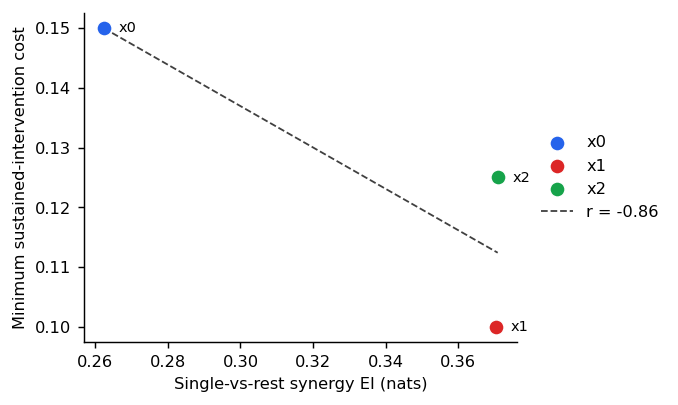

In [18]:
fig, ax = plt.subplots(figsize=(5.1, 3.0), constrained_layout=True)
for _, row in intervention_summary.iterrows():
    node = int(row["node"])
    ax.scatter(
        row["synergy"],
        row["min_intervention_cost"],
        s=70,
        color=ATTRACTOR_COLORS[node + 1],
        edgecolor="white",
        linewidth=0.8,
        label=f"x{node}",
        zorder=3,
    )
    ax.text(row["synergy"] + 0.004, row["min_intervention_cost"], f"x{node}", va="center", fontsize=8)
if len(valid_cost) >= 2:
    coef = np.polyfit(valid_cost["synergy"], valid_cost["min_intervention_cost"], deg=1)
    xs = np.linspace(valid_cost["synergy"].min(), valid_cost["synergy"].max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color="0.25", lw=1.0, ls="--", label=f"r = {pearson_synergy_cost:.2f}")
ax.set_xlabel("Single-vs-rest synergy EI (nats)")
ax.set_ylabel("Minimum sustained-intervention cost")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()

## 协同-成本对照结论

这个对照检验的是排序关系：节点的 $\mathrm{Syn}_i$ 越高，是否越容易用较低的持续干预成本 $C_i^*=\min \Delta T$ 把系统从原点 basin 推入对应高态 basin。由于这里只有三个节点，相关系数只作为机制示例；更强的验证需要在更多节点、更多随机非对称参数组或更大网络上重复。